In [27]:
import numpy as np
import matplotlib.pyplot as pl
from scipy.interpolate import CubicSpline
import scipy as sp
from scipy import integrate

c = 3e8
G = 6.67e-11
pi = np.pi
const = 96/5*pi**(8/3)*(G/c**3)**(5/3)
day = 86400

## Interpolating ephemeris

In [2]:
ephemeris = np.loadtxt("earth00-40-DE440.dat", delimiter = '\t', skiprows=18)

In [3]:
[t_eph, pos_x, pos_y, pos_z, vel_x, vel_y, vel_z, 
 acc_x, acc_y, acc_z] = ephemeris.T
v_arr = np.array([vel_x, vel_y, vel_z])
acc_arr = np.array([acc_x, acc_y, acc_z])

interp_v = CubicSpline(t_eph, v_arr.T)
interp_acc = CubicSpline(t_eph, acc_arr.T)

## Injecting

In [4]:
def f_calc(f0, beta, t):
    return f0*(1-8/3*beta*t)**(-3/8)

def phi_calc(f0, beta, t):
    return -6*pi/5*f0*(1-8./3.*beta*t)**(5/8)/beta

In [5]:
H_lat = 119.41 * np.pi/180 # rad
H_lng = 46.45 * np.pi/180 # rad

params = dict(ra = 0.5, dec = 0.5, eta = 0.5, psi = 0.5, lat = H_lat, 
              lng = H_lng, az = 0.5)

n_hat = (np.cos(params['ra'])*np.cos(params['dec']),
        np.sin(params['ra'])*np.cos(params['dec']),
        np.sin(params['dec']))

f0 = 10
Mc = 1e-3 * 2e30
beta = const*f0**(8/3)*Mc**(5/3)

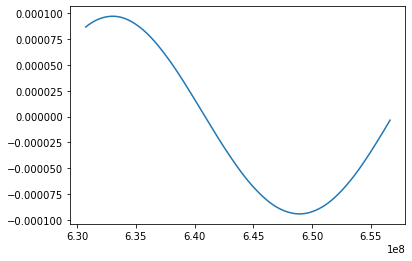

In [6]:
# Using t=30 days for long enough to see Doppler effects
t_space = np.linspace(t_eph[0], t_eph[0]+300*day, int(1e5))
f_source = f_calc(f0, beta, t_space - t_space[0])
f_doppler = f_source*(1+np.dot(interp_v(t_space), n_hat))
pl.plot(t_space, ((f_source - f_doppler)/f_source)) #Check you can see the effects

## 1st order solution 

$$\phi^{doppler}(t) = \phi^0(t) (1+\frac{\vec{v} \cdot \hat{n}}{c})$$

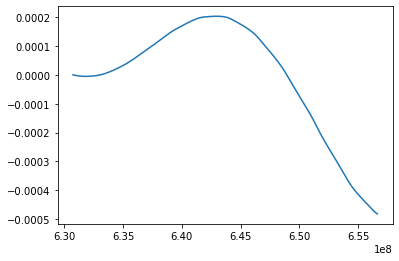

In [18]:
phi_source = phi_calc(f0, beta, t_space - t_space[0])
phi_source -= phi_source[0] #be careful with this
order1 = phi_source * (1+np.dot(interp_v(t_space), n_hat))

f_order1 = 1/(2*pi)*np.gradient(order1, np.diff(t_space)[0])
pl.plot(t_space, (f_order1 - f_doppler)/f_doppler)

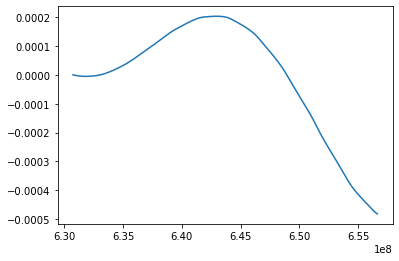

In [19]:
# pl.plot(t_space, f_doppler)
# pl.plot(t_space, f_approx)
pl.plot(t_space, (f_order1 - f_doppler)/f_doppler)

In [20]:
print("1st order solution is not sufficient")

1st order solution is not sufficient


## 2nd order solution

$$\phi^{doppler}(t) = \phi^0(t) (1+\frac{\vec{v} \cdot \hat{n}}{c})-\frac{\vec{a} \cdot \hat{n}}{c}\int\phi^0(t)dt$$

In [21]:
from scipy import integrate
integrated_phi = integrate.cumulative_trapezoid(phi_source, x=t_space, initial=0)
analytical_integrated = 6*np.pi*f0*(t_space-t_space[0])/(5*beta) \
                        * (1-(1-8/3*beta*(t_space-t_space[0]))**(5/8))

Why factor of 1/2?


/home/neil/anaconda3/envs/PBHs/lib/python3.7/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in true_divide
  """Entry point for launching an IPython kernel.


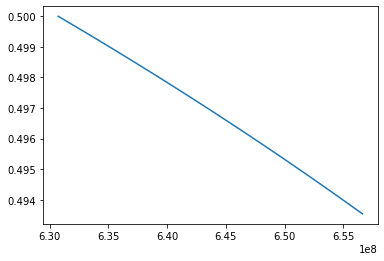

In [37]:
pl.plot(t_space, integrated_phi/analytical_integrated)
# pl.plot(t_space, analytical_integrated)
print("Why factor of 1/2?")

In [48]:
phi_source = phi_calc(f0, beta, t_space - t_space[0])
phi_source -= phi_source[0]
phi_approx = phi_source * (1+np.dot(interp_v(t_space), n_hat))\
             -np.dot(interp_acc(t_space), n_hat)*integrated_phi

f_approx = 1/(2*pi)*np.gradient(phi_approx, np.diff(t_space)[0])

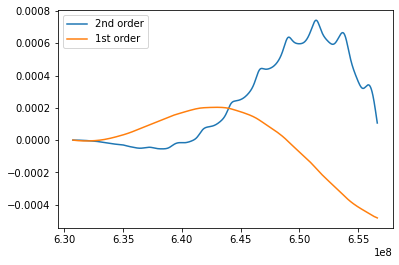

In [51]:
pl.plot(t_space, (f_approx - f_doppler)/f_doppler, label='2nd order')
pl.plot(t_space, (f_order1 - f_doppler)/f_doppler, label='1st order')
pl.legend()

## Numerically integrating

In [52]:
from scipy import integrate
phi_source = phi_calc(f0, beta, t_space - t_space[0])
phi_source -= phi_source[0]
phi_approx = phi_source * (1+np.dot(interp_v(t_space), n_hat))
f_approx  = 1/(2*pi)*np.gradient(phi_approx, np.diff(t_space)[0])
temp = -np.dot(interp_acc(t_space), n_hat)*phi_source

numerical = integrate.cumulative_trapezoid(temp, x=t_space, initial=0)
numerical_f = 1/(2*pi)*np.gradient(phi_approx+numerical, np.diff(t_space)[0])

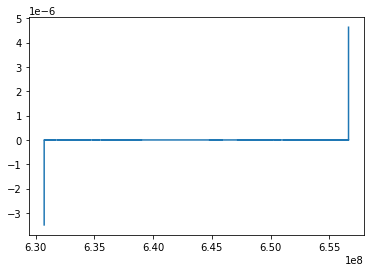

In [53]:
# pl.plot(t_space, (f_doppler - f_approx))
pl.plot(t_space, f_doppler - numerical_f)

In [1]:
# pl.plot(t_space, numerical)
pl.plot(t_space, np.dot(interp_acc(t_space), n_hat))
pl.plot(t_space, -numerical/integrated_phi)

NameError: name 'pl' is not defined

In [55]:
from scipy import integrate
numerical_phi = 2*np.pi*integrate.cumulative_trapezoid(f_doppler, x=t_space, initial=0)
numerical_f = 1/(2*pi)*np.gradient(numerical_phi, np.diff(t_space)[0])

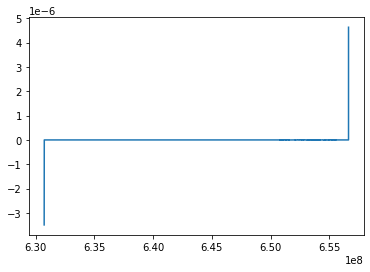

In [56]:
# pl.plot(t_space, (f_doppler - f_approx))
pl.plot(t_space, f_doppler - numerical_f)

In [57]:
temp0 = numerical_phi-numerical_phi[1]
temp1 = order1-order1[0]
temp2 = np.dot(interp_v(t_space), n_hat)

In [173]:
%matplotlib qt

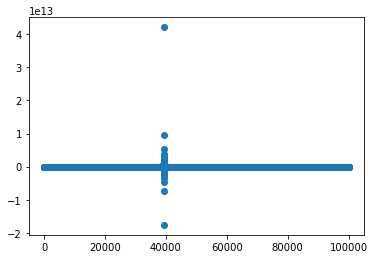

In [58]:
pl.plot((temp0 - temp1)/temp2, 'o')
# pl.xlim(-1e14, 1e14)

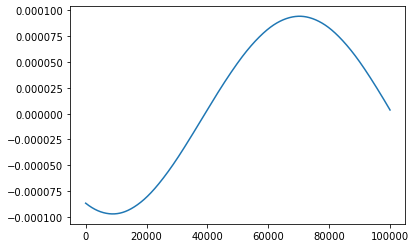

In [165]:
pl.plot(temp2)

In [ ]:
phi_source = phi_calc(f0, beta, t_space - t_space[0])
phi_source -= phi_source[0]
phi_approx = phi_source * (1+np.dot(interp_v(t_space), n_hat))
f_approx  = 1/(2*pi)*np.gradient(phi_approx, np.diff(t_space)[0])
temp = -np.dot(interp_acc(t_space), n_hat)*phi_source

numerical = integrate.cumulative_trapezoid(temp, x=t_space, initial=0)
numerical_f = 1/(2*pi)*np.gradient(phi_approx+numerical, np.diff(t_space)[0])